In [1]:
import os
import sys
from pathlib import Path

# Resolve repository root and set working directory
root = Path.cwd().resolve()
while root != root.parent:
    if (root / 'src').exists() and (root / 'config').exists():
        break
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))
os.chdir(root)
print(f'Working directory set to: {root}')


Working directory set to: C:\Users\given\Downloads\dozer-predictive-maintenance\dozer_predictive_maintenance


# 01. Data Understanding & Telemetry Ingestion Contract

This notebook performs comprehensive ingestion validation, schema inspection, operating hour (SMR) tracking, and ground-truth event mapping across the continuous mining dozers.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.data.load_data import load_workbook
from src.utils.io import load_config

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

config = load_config()
workbook = load_workbook(config["project"]["raw_file"])

telemetry = workbook["telemetry"]
events = workbook["events"]
metadata = workbook["metadata"]
thresholds = workbook["thresholds"]


## 1. Dataset Overview & Schema Inspection


In [3]:
print("=== TELEMETRY DATASET INFO ===")
telemetry.info()
print("\nTelemetry Shape:", telemetry.shape)
display(telemetry.head(10))


=== TELEMETRY DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 6602 entries, 1 to 6602
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Machine ID            6602 non-null   object        
 1   SMR                   6602 non-null   object        
 2   Timestamp             6602 non-null   datetime64[ns]
 3   Engine Speed Max      6379 non-null   object        
 4   Engine Speed Avg      6349 non-null   object        
 5   Blow-by Press Max     6361 non-null   object        
 6   Oil Press LoIdle Min  6374 non-null   object        
 7   Oil Press HiIdle Min  6390 non-null   object        
 8   Oil Temp Max          6394 non-null   object        
 9   Coolant Temp Max      6379 non-null   object        
 10  Boost Press Max       6377 non-null   object        
 11  LB Front Exh Temp     6367 non-null   object        
 12  LB Rear Exh Temp      6383 non-null   object      

## 2. Fleet Breakdown & Temporal Continuity


In [4]:
print("Observations per Dozer:")
print(telemetry["Machine ID"].value_counts())

fleet_summary = telemetry.groupby("Machine ID").agg(
    start_timestamp=("Timestamp", "min"),
    end_timestamp=("Timestamp", "max"),
    total_operating_hours=("Timestamp", "count"),
    min_smr=("SMR", "min"),
    max_smr=("SMR", "max")
).reset_index()

print("\n=== FLEET OPERATIONAL SUMMARY ===")
display(fleet_summary)


Observations per Dozer:
Machine ID
DZ-104    1696
DZ-118    1671
DZ-127    1640
DZ-142    1595
Name: count, dtype: int64

=== FLEET OPERATIONAL SUMMARY ===
  Machine ID     start_timestamp  ... min_smr  max_smr
0     DZ-104 2025-01-01 06:00:00  ...    8501    10196
1     DZ-118 2025-01-01 06:00:00  ...   15201    16871
2     DZ-127 2025-01-01 05:00:00  ...   11301    12940
3     DZ-142 2025-01-01 05:00:00  ...    6101     7695

[4 rows x 6 columns]


## 3. Ground-Truth Event Categorization

Only **Unplanned Failure** represents true mechanical failures. **False Alarm** and **Scheduled Maintenance** must be mapped to negative targets to avoid false-label corruption.


=== GROUND TRUTH EVENTS ===
  Machine ID  ...                                              Notes
0     DZ-142  ...  Inspection triggered by dashboard alert. No me...
1     DZ-104  ...  Planned maintenance, not related to any anomal...
2     DZ-127  ...  Progressive loss of blade response over the pr...
3     DZ-118  ...  Machine pulled from service after operator rep...

[4 rows x 7 columns]


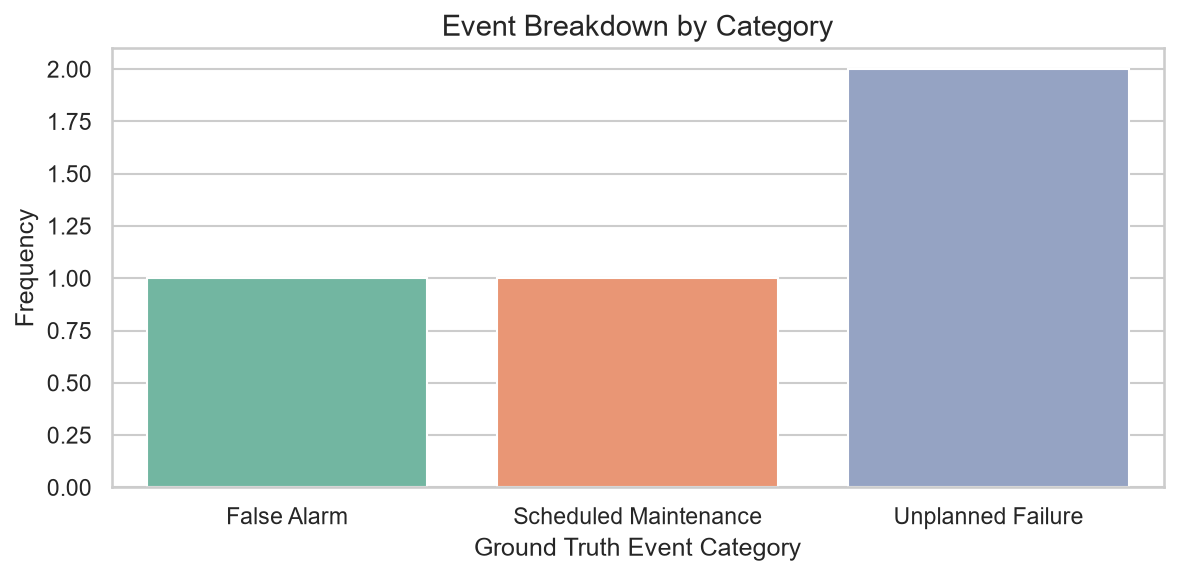

In [5]:
print("=== GROUND TRUTH EVENTS ===")
display(events)

plt.figure(figsize=(8, 4))
sns.countplot(data=events, x="Category", palette="Set2")
plt.title("Event Breakdown by Category", fontsize=14)
plt.xlabel("Ground Truth Event Category")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 4. OEM Engineering Thresholds

OEM thresholds provide domain engineering guidance for feature extraction. They are features, **never labels**.


In [6]:
print("=== OEM DOMAIN THRESHOLDS ===")
display(thresholds)


=== OEM DOMAIN THRESHOLDS ===
               Parameter  ...                                         Indicators
0      Blow-by Press Max  ...    High blow-by indicates worn piston rings/liners
1   Oil Press LoIdle Min  ...  Low oil pressure at idle indicates pump wear o...
2   Oil Press HiIdle Min  ...  Low oil pressure at high idle indicates lubric...
3           Oil Temp Max  ...  High oil temp causes oxidation and viscosity b...
4       Coolant Temp Max  ...                    Overheating risks engine damage
5        Boost Press Max  ...          Excessive boost may indicate turbo issues
6      LB Front Exh Temp  ...  High exhaust temp indicates fueling/timing issues
7       LB Rear Exh Temp  ...  High exhaust temp indicates fueling/timing issues
8      RB Front Exh Temp  ...  High exhaust temp indicates fueling/timing issues
9       RB Rear Exh Temp  ...  High exhaust temp indicates fueling/timing issues
10      Hyd Oil Temp Max  ...       High hydraulic temp degrades seals and flui

## 5. Telemetry Missing Value Audit


In [7]:
missing_df = telemetry.isnull().sum().reset_index()
missing_df.columns = ["Column", "Missing_Count"]
missing_df["Missing_Percentage"] = (missing_df["Missing_Count"] / len(telemetry)) * 100
display(missing_df)


                  Column  Missing_Count  Missing_Percentage
0             Machine ID              0            0.000000
1                    SMR              0            0.000000
2              Timestamp              0            0.000000
3       Engine Speed Max            223            3.377764
4       Engine Speed Avg            253            3.832172
5      Blow-by Press Max            241            3.650409
6   Oil Press LoIdle Min            228            3.453499
7   Oil Press HiIdle Min            212            3.211148
8           Oil Temp Max            208            3.150560
9       Coolant Temp Max            223            3.377764
10       Boost Press Max            225            3.408058
11     LB Front Exh Temp            235            3.559527
12      LB Rear Exh Temp            219            3.317177
13     RB Front Exh Temp            226            3.423205
14      RB Rear Exh Temp            239            3.620115
15             Fuel Rate            219 